In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd

plt.rcParams.update({
    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    # Fonts
    "font.size": 14,          # base font size
    "axes.titlesize": 16,     # title
    "axes.labelsize": 16,     # x,y labels

    # Tick labels
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    # Legend
    "legend.fontsize": 13,
    "legend.frameon": False,

    # Lines
    "lines.linewidth": 2,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.3,

    # Better layout
    "figure.autolayout": True,

    "text.usetex": False,   # set True if LaTeX installed
    "font.family": "serif",
    "mathtext.fontset": "stix",
})

### Building R and X matrix for calculating Voltages later.

In [2]:
## Building the R and X matrices for the linearized voltage model
## These are also sensitivity matrices for how load changes at each bus affect voltage at each bus, relative to the root bus.

def build_tree_from_lines(line_df, root=114):

    children = defaultdict(list)
    parent = {}
    edge_rx = {}

    for _, row in line_df.iterrows():
        i = int(row["upstream bus"])
        j = int(row["downstream bus"])
        r = float(row["series resistance (pu)"])
        x = float(row["series reactance (pu)"])

        children[i].append(j)
        parent[j] = i
        edge_rx[(i, j)] = (r, x)

    buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"])))
    non_root = [b for b in buses if b != root]

    return children, parent, edge_rx, buses, non_root


# It returns the list of edges on the path from a given bus to the root bus, in order from root to bus.
def path_edges_to_root(bus, parent):
    edges = []
    cur = bus
    while cur in parent:
        par = parent[cur]
        edges.append((par, cur))
        cur = par
    edges.reverse()
    return edges


def build_RX_matrices(line_df, root=0):
    
    children, parent, edge_rx, buses, non_root = build_tree_from_lines(line_df, root=root)
    n = len(non_root)

    bus_to_idx = {b: k for k, b in enumerate(non_root)}
    path_map = {b: path_edges_to_root(b, parent) for b in non_root}

    R = np.zeros((n, n), dtype=float)
    X = np.zeros((n, n), dtype=float)

    for bi in non_root:
        for bj in non_root:
            common = set(path_map[bi]).intersection(set(path_map[bj]))  # Only the common edges contribute to the voltage drop difference between bi and bj
            r_sum = sum(edge_rx[e][0] for e in common)
            x_sum = sum(edge_rx[e][1] for e in common)

            i = bus_to_idx[bi]
            j = bus_to_idx[bj]
            R[i, j] = 2.0 * r_sum
            X[i, j] = 2.0 * x_sum

    return R, X, non_root, bus_to_idx

In [3]:
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)

### Building Bus loads

In [4]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]



In [5]:
buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"]))) # removing the root bus
buses.remove(114)
bldgs = df.index.get_level_values("bldg_id").unique()

np.random.seed(0)

bus_assignment = pd.DataFrame({
    "bldg_id": bldgs,
    "bus": np.random.choice(buses, size=len(bldgs))
})

In [6]:
df.reset_index(inplace=True)

df = df.merge(bus_assignment, on="bldg_id")

bus_load = (
    df
    .groupby(["timestamp","bus"])["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [7]:
bus_load = bus_load.pivot(
    index="timestamp",
    columns="bus",
    values="out.electricity.net.energy_consumption"
)

bus_load = bus_load.fillna(0)

# Forcing all the buses to  exist even if they have no load
bus_load = bus_load.reindex(columns=buses, fill_value=0.0)

In [8]:
bus_load_kw = bus_load / 0.25 # Converting to KW : P = E/t


# --- Step 1: scale loads for voltage feasibility FIRST ---
peak_load_kw_raw = bus_load_kw.sum(axis=1).max()
S_base_temp = peak_load_kw_raw # temporary maximum power as base to calculate per-unit loads for voltage constraint evaluation.
bus_load_pu_temp = bus_load_kw / S_base_temp

pf = np.full(bus_load_pu_temp.shape[1], 0.9)
eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)
Z = R + X @ np.diag(eta_bus)

v_base = 1.0 - (bus_load_pu_temp.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("Raw peak load (kW):", peak_load_kw_raw)
print("Minimum baseline voltage before scaling:", vmin_actual)

# scaling all loads down so minimum voltage becomes 0.95 p.u.
scale_voltage = (1.0 - 0.95) / (1.0 - vmin_actual)
bus_load_kw_scaled = bus_load_kw * scale_voltage


# Step 2: setting transformer capacity AFTER voltage scaling 
peak_load_kw_scaled = bus_load_kw_scaled.sum(axis=1).max()
S_base = peak_load_kw_scaled
bus_load_pu = bus_load_kw_scaled / S_base  # Converting to per unit

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("\n")
print("Applied voltage scaling factor:", scale_voltage)
print("Peak load after voltage scaling (kW):", peak_load_kw_scaled)
print("Transformer rating S_base (kW):", S_base)
print("Peak load in pu after voltage scaling:", bus_load_pu.sum(axis=1).max())
print("Minimum baseline voltage after scaling:", vmin_actual)


# --- Step 3: further scale loads down to create headroom ---
bus_load_pu = 0.9 * bus_load_pu   # this is what we will use for the rest of analysis.
bus_load_kw_final = 0.9 * bus_load_kw_scaled # this is what we will use for the rest of analysis.

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_final = v_base.min()

print("\n")
print("Final peak load after headroom scaling (kW):", bus_load_kw_final.sum(axis=1).max())
print("Transformer rating remains fixed (kW):", S_base)
print("Final peak load in pu:", bus_load_pu.sum(axis=1).max())
print("Minimum voltage after headroom scaling:", vmin_final)
print("Available headroom at peak (pu):", 1.0 - bus_load_pu.sum(axis=1).max())
print("Available headroom at peak (kW):", S_base - bus_load_kw_final.sum(axis=1).max())



Raw peak load (kW): 464.5039999999999
Minimum baseline voltage before scaling: 0.9463326002665228


Applied voltage scaling factor: 0.9316642924440125
Peak load after voltage scaling (kW): 432.76179049741353
Transformer rating S_base (kW): 432.76179049741353
Peak load in pu after voltage scaling: 1.0
Minimum baseline voltage after scaling: 0.9463326002665228


Final peak load after headroom scaling (kW): 389.4856114476723
Transformer rating remains fixed (kW): 432.76179049741353
Final peak load in pu: 0.8999999999999999
Minimum voltage after headroom scaling: 0.9516993402398705
Available headroom at peak (pu): 0.10000000000000009
Available headroom at peak (kW): 43.276179049741245


### EV Charging Dataset (Norway)

In [9]:
ev_df = pd.read_csv('EV/dataset_3a_aggregated.csv', sep=';')
ev_df = ev_df[['date_from', 'Synthetic_7_2kW']]

ev_df['Synthetic_7_2kW'] = (
    ev_df['Synthetic_7_2kW']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

ev_df['date_from'] = pd.to_datetime(ev_df['date_from'], dayfirst=True)
ev_df = ev_df.set_index('date_from').sort_index()

ev_df.drop_duplicates(inplace=True)

# Resampling to 15-minutes interval
ev_df = ev_df.resample('15T').interpolate(method='linear')
ev_df =  ev_df.loc['2019-01-01 00:15:00':'2020-01-01 00:00:00']
ev_df.index = ev_df.index - pd.DateOffset(years=12)

C:\Users\gcsar\AppData\Local\Temp\ipykernel_24020\105924172.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ev_df = ev_df.resample('15T').interpolate(method='linear')


### Base and EV data visualization

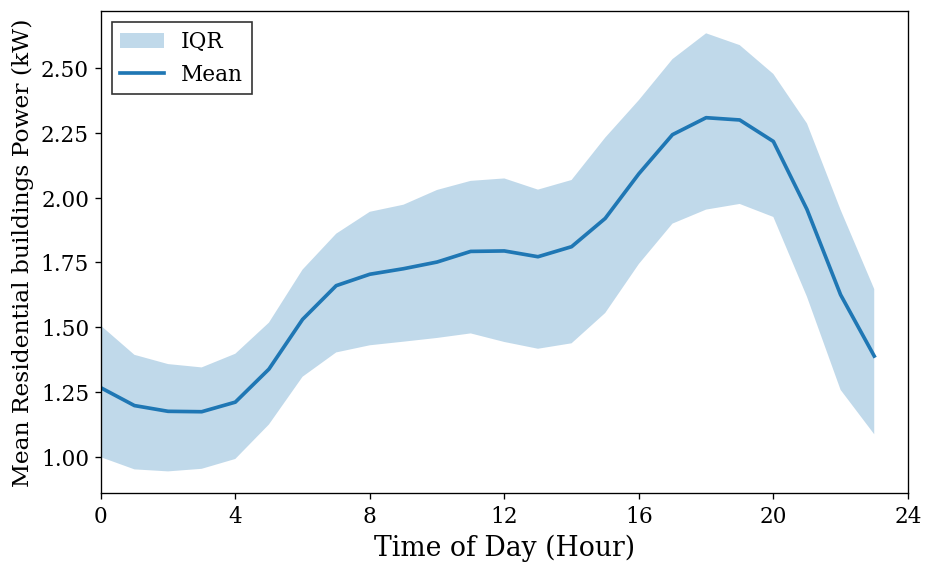

In [10]:
base_load = bus_load_kw_final.mean(axis=1)

def hourly_mean_iqr(series):
    df = pd.DataFrame({"value": series})
    df["hour"] = df.index.hour

    stats = df.groupby("hour")["value"].agg([
        ("q25", lambda x: np.percentile(x, 25)),
        ("mean", "mean"),
        ("q75", lambda x: np.percentile(x, 75)),
    ])
    return stats

res_stats = hourly_mean_iqr(base_load)

# Residential power plot
plt.figure(figsize=(8, 5))
h = res_stats.index.to_numpy()
m = res_stats["mean"].to_numpy()
q25 = res_stats["q25"].to_numpy()
q75 = res_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Mean Residential buildings Power (kW)", fontsize=14)
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


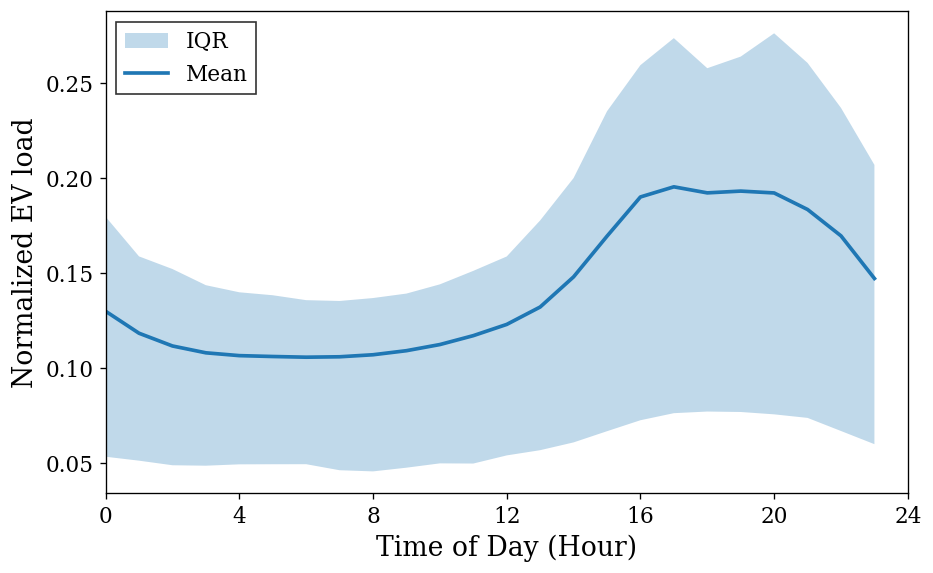

In [11]:
ev_df_plot = ev_df.copy()
ev_df_plot['Synthetic_7_2kW'] = ev_df_plot['Synthetic_7_2kW']/ev_df_plot['Synthetic_7_2kW'].max()

ev_stats = hourly_mean_iqr(ev_df_plot['Synthetic_7_2kW']) 

# Residential power plot
plt.figure(figsize=(8, 5))
h = ev_stats.index.to_numpy()
m = ev_stats["mean"].to_numpy()
q25 = ev_stats["q25"].to_numpy()
q75 = ev_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Normalized EV load")
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


### Hosting Capacity

In [12]:
def dynamic_hosting_capacity_network(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.97,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    C_res = np.full(T, np.inf, dtype=float)
    C_dyn = np.full(T, np.inf, dtype=float)

    l_agg = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - l_agg[t]

        # voltage headroom
        numerator = v0 - vmin - (Z @ ell)
        denominator = Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        C_res[t] = min(headroom_tx, headroom_v)
        # C_res[t] = headroom_tx

        if lhat_new[t] > 1e-12:
            C_dyn[t] = C_res[t] / lhat_new[t]
        else:
            C_dyn[t] = np.inf

    return C_res, C_dyn

In [13]:
# Normalized flexible load profile (EV charing profile in this case)

ev_profile = ev_df["Synthetic_7_2kW"].copy()
ev_profile = ev_profile.reindex(bus_load_pu.index)

# normalize
lhat = ev_profile.to_numpy(dtype=float)
lhat = lhat / lhat.max()

print("Length of lhat:", len(lhat))
print("Min/Max of lhat:", lhat.min(), lhat.max())

# or comment out all above and use the following dummy lhat for testing
# lhat = np.ones(len(bus_load_pu)) # Normalized load

Length of lhat: 35040
Min/Max of lhat: 0.0001314233144959916 1.0


### Gu paper result

In [14]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95


C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.97,
)

# finite times only
finite_mask = np.isfinite(C_dyn)
C_dyn_finite = C_dyn[finite_mask]
idx_finite = np.where(finite_mask)[0]

# sort
order = np.argsort(C_dyn_finite)
C_sorted = C_dyn_finite[order]
t_sorted = idx_finite[order]

K = 350   # example: allow curtailment at 100 time steps

C_star_K = C_sorted[K]   # zero-based indexing => (K+1)-th smallest
critical_times = t_sorted[:K]

In [15]:
print('hosting capacity at K-th critical time step:', C_star_K*S_base)

u_star = np.zeros(T)

for t in critical_times:
    u_star[t] = C_res[t] - C_star_K * lhat[t]

hosting capacity at K-th critical time step: 325.04947557750444


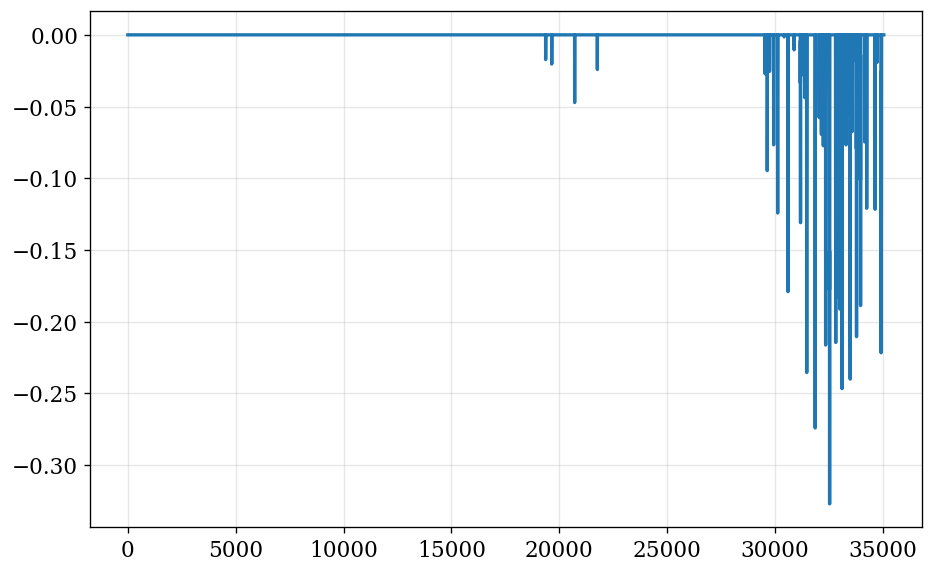

In [15]:
plt.plot(u_star)

In [16]:
def hosting_capacity_under_depth(C_dyn, lhat, K, mu, tol=1e-10):

    C_dyn = np.asarray(C_dyn, dtype=float)
    lhat = np.asarray(lhat, dtype=float)

    if C_dyn.shape != lhat.shape:
        raise ValueError("C_dyn and lhat must have the same shape.")

    active = (lhat > tol) & np.isfinite(C_dyn)
    if not np.any(active):
        return np.inf, np.zeros_like(lhat), np.array([], dtype=int)

    a = np.full_like(C_dyn, np.inf, dtype=float)   # no-curtail bound
    b = np.full_like(C_dyn, np.inf, dtype=float)   # depth-limited curtail bound

    a[active] = C_dyn[active]

    if mu >= 1.0:
        b[active] = np.inf
    else:
        b[active] = C_dyn[active] / (1.0 - mu)

    candidates = np.unique(np.concatenate([a[active], b[active]]))
    candidates = np.sort(candidates[np.isfinite(candidates)])

    def feasible(C):
        # required curtailment amount at each time
        u_req = np.maximum(0.0, (C - C_dyn) * lhat)

        # per-time depth cap
        depth_ok = np.all(u_req <= mu * C * lhat + tol)

        # max number of interventions
        k_used = np.count_nonzero(u_req > tol)

        return depth_ok and (k_used <= K), u_req

    C_star = 0.0
    u_star = np.zeros_like(lhat)

    for C in candidates:
        ok, u_req = feasible(C)
        if ok:
            C_star = C
            u_star = u_req
        else:
            break

    curtailed_idx = np.where(u_star > tol)[0]
    return C_star, u_star, curtailed_idx

In [ ]:
# existing unconstrained-depth result
C_unconstrained = C_sorted[K]

# depth-limited result

mu = 0
C_depth, u_depth, idx_depth = hosting_capacity_under_depth(C_dyn, lhat, K, mu)

print("Unconstrained depth capacity :", C_unconstrained*S_base)
print("Depth-limited capacity       :", C_depth*S_base)
print("Capacity loss due to depth cap:",
      (C_unconstrained - C_depth)*S_base)

Unconstrained depth capacity : 325.04947557750444
Depth-limited capacity       : 162.72443356963612
Capacity loss due to depth cap: 162.32504200786832


### Optimization

In [77]:
def optimization(C_res, lhat, alpha=0.95, mu=0.10, lam=1e-4,
                 C_max=1.0, solver="GUROBI", verbose=True):
    T = len(C_res)

    C = cp.Variable(nonneg=True, name="C")
    u = cp.Variable(T, nonneg=True, name="u")
    eta = cp.Variable(name="eta")
    s = cp.Variable(T, nonneg=True, name="s")

    Cres_pos = np.maximum(C_res, 0.0)
    w = Cres_pos + 1e-3
    w = w / max(np.max(w), 1e-8)

    # zeta = cp.multiply(lhat, C) - u - C_res
    # constraints = [
    #     s >= zeta - eta,
    #     eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0,
    #     u <= mu * cp.multiply(lhat, C),
    # ]

    # constraints = [
    #     C * lhat - u <= C_res,
    #     s >= u - mu * C * lhat - eta,
    #     eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0
    # ]

    v = cp.Variable(T, nonneg=True)

    constraints = [
        C * lhat - u <= C_res,                # network constraint
        u <= mu * C * lhat + v,               # depth + slack

        s >= v - eta,                         # CVaR on violation only
        eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0
    ]

    if C_max is not None:
        constraints += [C <= C_max]

    obj = cp.Maximize(C - lam * cp.sum(cp.multiply(w, u)))
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=solver, verbose=verbose)

    return {
        "status": prob.status,
        "objective": None if prob.value is None else float(prob.value),
        "C": None if C.value is None else float(C.value),
        "eta": None if eta.value is None else float(eta.value),
        "u": None if u.value is None else np.asarray(u.value).flatten(),
        "s": None if s.value is None else np.asarray(s.value).flatten(),
        "w": w,
    }


In [78]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)


alpha = 0.95

# K = 350
# alpha = 1 - K/T  
epsilon = 0.0

# Curtailment budget parameters
dt = 0.25      # 15-minute intervals = 0.25 hour
mu = 0.1       # max 10% curtailment per timestamp

res = optimization(
    C_res=C_res,
    lhat=lhat,
    alpha=alpha,
    mu=mu,
    solver="CLARABEL",
    verbose=False,
    lam = 0
)

print("Status:", res["status"])
print("Optimal C:", res["C"])
print("Optimal C in kW:", None if res["C"] is None else res["C"] * S_base)
print("eta:", res["eta"])

Status: optimal
Optimal C: 0.4177931934066507
Optimal C in kW: 180.80493043629434
eta: 2.7740164747827765e-12


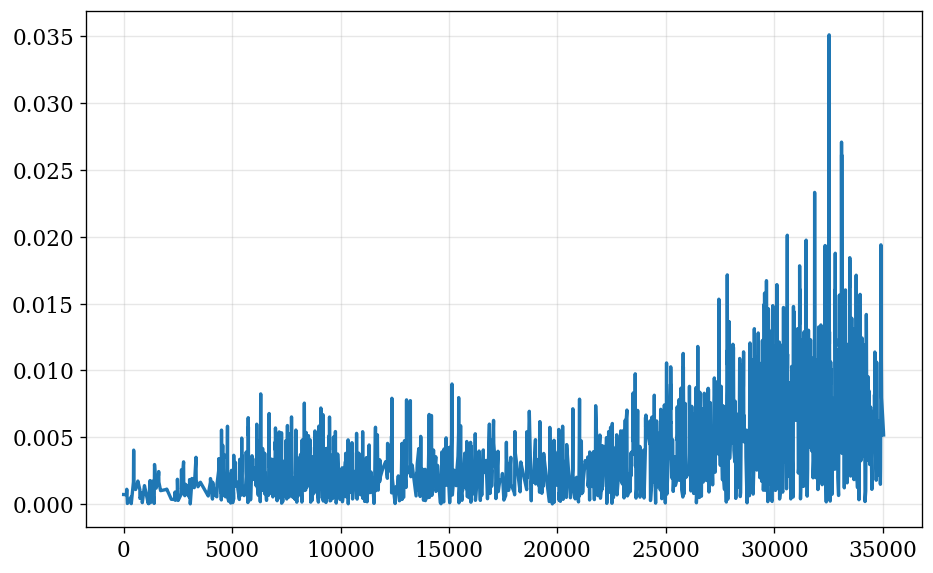

In [79]:
plt.plot(res["u"])

In [21]:
def tune_lambda_for_K(
    C_res,
    lhat,
    K_target,
    alpha=0.95,
    mu=0.1,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol_K=5,
    solver="CLARABEL",
    patience = 5
):
    T = len(C_res)
    tol = 1e-6

    best_res = None
    last_K = None
    stagnant_counter = 0

    for i in range(max_iter):
        lam_mid = 0.5 * (lam_low + lam_high)

        res = optimization(
            C_res=C_res,
            lhat=lhat,
            alpha=alpha,
            mu=mu,
            lam=lam_mid,
            solver=solver,
            verbose=False
        )

        if res["status"] not in ["optimal", "optimal_inaccurate"]:
            print("Solver failed at iteration", i)
            break

        u = res["u"]
        K_actual = np.sum(u > tol)

        print(f"Iter {i}: lam={lam_mid:.4e}, K={K_actual}, C={res['C']*S_base:.2f} kW")

        # Store best
        best_res = res

        # early stopping if K is not improving
        if last_K is not None and K_actual == last_K:
            stagnant_counter += 1
        else:
            stagnant_counter = 0

        last_K = K_actual

        if stagnant_counter >= patience:
            print(f"Early stopping: K unchanged for {patience} iterations")
            break

        # Check convergence
        if abs(K_actual - K_target) <= tol_K:
            
            print("Converged!")
            break

        # Bisection update
        if K_actual > K_target:
            lam_low = lam_mid   # need fewer interventions → increase λ
        else:
            lam_high = lam_mid  # need more interventions → decrease λ

    return best_res, lam_mid

In [75]:
best_res, best_lambda = tune_lambda_for_K(
    C_res=C_res,
    lhat=lhat,
    K_target=350,
    alpha=0.95,
    mu=0.1,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol_K=5,
    solver="CLARABEL"
)

Iter 0: lam=5.0000e-01, K=9, C=179.85 kW
Iter 1: lam=2.5000e-01, K=18, C=188.29 kW
Iter 2: lam=1.2500e-01, K=34, C=206.24 kW
Iter 3: lam=6.2501e-02, K=62, C=223.01 kW
Iter 4: lam=3.1251e-02, K=74, C=233.20 kW
Iter 5: lam=1.5626e-02, K=74, C=233.20 kW
Iter 6: lam=7.8135e-03, K=74, C=233.20 kW
Iter 7: lam=3.9072e-03, K=74, C=233.20 kW
Iter 8: lam=1.9541e-03, K=74, C=233.20 kW
Iter 9: lam=9.7756e-04, K=74, C=233.20 kW
Early stopping: K unchanged for 5 iterations


In [114]:
len(best_res["u"][best_res["u"] > 1e-4])

347

In [24]:
best_res['C'] * S_base

np.float64(180.80492662325165)

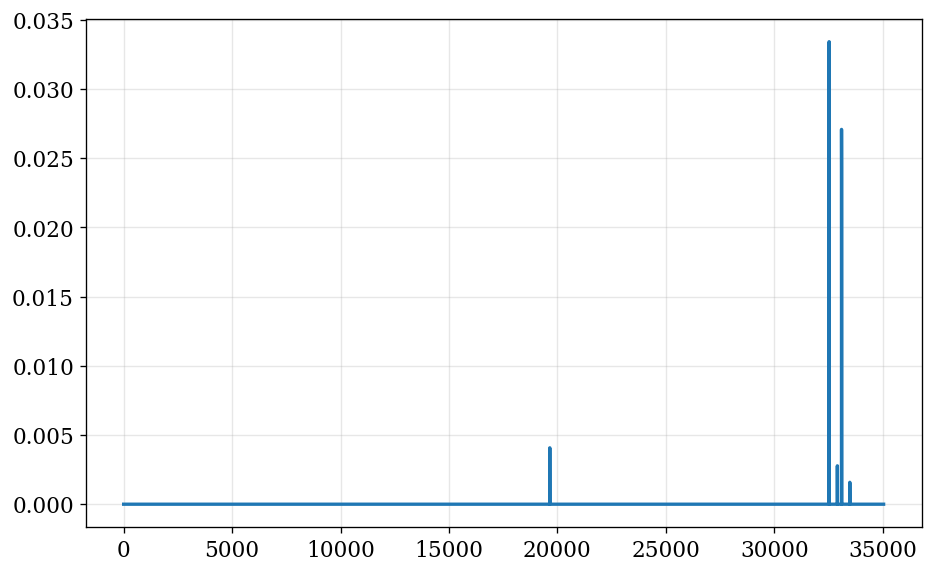

In [25]:
plt.plot(best_res["u"])

### Keep C fixed and solve for K

In [86]:
def optimization_stage1(
    C_res,
    lhat,
    alpha=0.95,
    mu=0.10,
    solver="GUROBI",
    verbose=True,
):
    import cvxpy as cp
    import numpy as np

    T = len(C_res)

    C = cp.Variable(nonneg=True, name="C")
    u = cp.Variable(T, nonneg=True, name="u")
    eta = cp.Variable(name="eta")
    s = cp.Variable(T, nonneg=True, name="s")

    constraints = [
        C * lhat - u <= C_res,
        s >= u - mu * C * lhat - eta,
        eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0,
    ]

    prob = cp.Problem(cp.Maximize(C), constraints)
    prob.solve(solver=solver, verbose=verbose)

    return {
        "status": prob.status,
        "objective": None if prob.value is None else float(prob.value),
        "C": None if C.value is None else float(C.value),
        "eta": None if eta.value is None else float(eta.value),
        "u": None if u.value is None else np.asarray(u.value).flatten(),
        "s": None if s.value is None else np.asarray(s.value).flatten(),
    }

In [87]:
def optimization_stage2(
    C_res,
    lhat,
    C_min,
    alpha=0.95,
    mu=0.10,
    lam=1e-4,
    solver="GUROBI",
    verbose=True,
):
    import cvxpy as cp
    import numpy as np

    T = len(C_res)

    C = cp.Variable(nonneg=True, name="C")
    u = cp.Variable(T, nonneg=True, name="u")
    eta = cp.Variable(name="eta")
    s = cp.Variable(T, nonneg=True, name="s")

    Cres_pos = np.maximum(C_res, 0.0)
    w = Cres_pos + 1e-3
    w = w / np.max(w)

    constraints = [
        C * lhat - u <= C_res,
        s >= u - mu * C * lhat - eta,
        eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0,
        C >= C_min,   # keep capacity near stage-1 optimum
    ]

    obj = cp.Maximize(C - lam * cp.sum(cp.multiply(w, u)))
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=solver, verbose=verbose)

    return {
        "status": prob.status,
        "objective": None if prob.value is None else float(prob.value),
        "C": None if C.value is None else float(C.value),
        "eta": None if eta.value is None else float(eta.value),
        "u": None if u.value is None else np.asarray(u.value).flatten(),
        "s": None if s.value is None else np.asarray(s.value).flatten(),
        "w": w,
        "lam": lam,
    }

In [89]:
def tune_lambda_stage2(
    C_res,
    lhat,
    C_star,
    K_target,
    alpha=0.95,
    mu=0.10,
    capacity_tol=1e-4,   # keep at least (1 - capacity_tol) * C_star
    lam_low=1e-8,
    lam_high=1e2,
    max_iter=40,
    patience=6,
    k_tol=0,
    u_tol=1e-6,
    solver="GUROBI",
    verbose=False,
):
    import numpy as np

    C_min = (1.0 - capacity_tol) * C_star

    best_res = None
    best_gap = np.inf
    best_lam = None

    last_K = None
    stagnant = 0

    for i in range(max_iter):
        lam_mid = 0.5 * (lam_low + lam_high)

        res = optimization_stage2(
            C_res=C_res,
            lhat=lhat,
            C_min=C_min,
            alpha=alpha,
            mu=mu,
            lam=lam_mid,
            solver=solver,
            verbose=verbose,
        )

        if res["status"] not in ["optimal", "optimal_inaccurate"]:
            print(f"Iteration {i}: solver failed at lam={lam_mid:.3e}")
            break

        u = res["u"]
        K_actual = int(np.sum(u > u_tol))
        gap = abs(K_actual - K_target)

        print(
            f"iter={i:02d}, lam={lam_mid:.3e}, "
            f"C={res['C']:.6f}, K={K_actual}"
        )

        if gap < best_gap:
            best_gap = gap
            best_res = res
            best_lam = lam_mid

        # patience on unchanged K
        if last_K is not None and K_actual == last_K:
            stagnant += 1
        else:
            stagnant = 0
        last_K = K_actual

        if stagnant >= patience:
            print(f"Stopping early: K unchanged for {patience} iterations.")
            break

        # stop if target met
        if K_actual <= K_target + k_tol:
            print("Target met.")
            best_res = res
            best_lam = lam_mid
            break

        # monotonic update:
        # too many interventions -> increase lambda
        if K_actual > K_target:
            lam_low = lam_mid
        else:
            lam_high = lam_mid

    return {
        "best_result": best_res,
        "best_lambda": best_lam,
        "best_gap": best_gap,
        "C_star_stage1": C_star,
        "C_min_stage2": C_min,
    }

In [90]:
def two_stage_capacity(
    C_res,
    lhat,
    K_target,
    alpha=0.95,
    mu=0.10,
    capacity_tol=1e-4,
    lam_low=1e-8,
    lam_high=1e2,
    max_iter=40,
    patience=6,
    u_tol=1e-6,
    solver="GUROBI",
    verbose_stage1=False,
    verbose_stage2=False,
):
    # Stage 1: maximize capacity
    res1 = optimization_stage1_capacity(
        C_res=C_res,
        lhat=lhat,
        alpha=alpha,
        mu=mu,
        solver=solver,
        verbose=verbose_stage1,
    )

    if res1["status"] not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"Stage 1 failed with status: {res1['status']}")

    C_star = res1["C"]
    print(f"Stage 1 complete: C* = {C_star:.6f}")

    # Stage 2: tune lambda for sparse interventions
    res2 = tune_lambda_stage2(
        C_res=C_res,
        lhat=lhat,
        C_star=C_star,
        K_target=K_target,
        alpha=alpha,
        mu=mu,
        capacity_tol=capacity_tol,
        lam_low=lam_low,
        lam_high=lam_high,
        max_iter=max_iter,
        patience=patience,
        u_tol=u_tol,
        solver=solver,
        verbose=verbose_stage2,
    )

    return {
        "stage1": res1,
        "stage2": res2,
    }

In [91]:
K_target = 350

result = two_stage_capacity(
    C_res=C_res,
    lhat=lhat,
    K_target=K_target,
    alpha=0.95,
    mu=0.10,
    capacity_tol=1e-4,
    lam_low=1e-8,
    lam_high=1e2,
    max_iter=40,
    patience=5,
    u_tol=1e-6,
    solver="CLARABEL",
    verbose_stage1=False,
    verbose_stage2=False,
)

res1 = result["stage1"]
res2 = result["stage2"]["best_result"]

print("\nStage 1")
print("status:", res1["status"])
print("C*:", res1["C"])

print("\nStage 2")
print("best lambda:", result["stage2"]["best_lambda"])
print("status:", res2["status"])
print("C:", res2["C"])
print("K:", (res2["u"] > 1e-6).sum())

Stage 1 complete: C* = 0.538862
iter=00, lam=5.000e+01, C=0.538808, K=74
Target met.

Stage 1
status: optimal
C*: 0.5388623782796447

Stage 2
best lambda: 50.000000005
status: optimal
C: 0.5388084920544709
K: 74


### Hosting capacity vs. K

In [26]:
# ===== Baseline (no curtailment) =====
tol = 1e-9
mask = lhat > tol
C_base = np.min(C_res[mask] / lhat[mask])
C_base_kw = C_base * S_base

print(f"Baseline capacity = {C_base_kw:.2f} kW")

# ===== Setup =====
K_vals = [0, 50, 100, 150, 200, 250, 300, 350]
mu_list = [0.0, 0.05, 0.10, 0.15, 0.20]

results_K = {}

for mu in mu_list:
    gain_vals = []

    print(f"\n===== Running for mu = {mu} =====")

    for K_target in K_vals:
        if K_target == 0:
            gain_vals.append(0.0)
            print(f"K={K_target}, gain=0%")
            continue

        best_res, lam_opt = tune_lambda_for_K(
            C_res=C_res,
            lhat=lhat,
            K_target=K_target,
            alpha=0.95,
            mu=mu,
            lam_low=1e-6,
            lam_high=1.0,
            max_iter=30,
            tol_K=5,
            solver="CLARABEL",
            patience=5
        )

        if best_res is None or best_res["status"] not in ["optimal", "optimal_inaccurate"]:
            gain_vals.append(np.nan)
            print(f"K={K_target}, status=failed")
        else:
            C_kw = best_res["C"] * S_base
            gain_pct = 100.0 * (C_kw - C_base_kw) / C_base_kw
            gain_vals.append(gain_pct)

            K_actual = np.sum(best_res["u"] > 1e-6)
            print(
                f"K_target={K_target}, "
                f"K_actual={K_actual}, "
                f"gain={gain_pct:.2f}%"
            )

    results_K[mu] = np.array(gain_vals)


Baseline capacity = 162.72 kW

===== Running for mu = 0.0 =====
K=0, gain=0%
Iter 0: lam=5.0000e-01, K=0, C=162.72 kW
Iter 1: lam=2.5000e-01, K=0, C=162.72 kW
Iter 2: lam=1.2500e-01, K=0, C=162.72 kW
Iter 3: lam=6.2501e-02, K=0, C=162.72 kW
Iter 4: lam=3.1251e-02, K=0, C=162.72 kW
Iter 5: lam=1.5626e-02, K=0, C=162.72 kW
Early stopping: K unchanged for 5 iterations
K_target=50, K_actual=0, gain=0.00%
Iter 0: lam=5.0000e-01, K=0, C=162.72 kW
Iter 1: lam=2.5000e-01, K=0, C=162.72 kW
Iter 2: lam=1.2500e-01, K=0, C=162.72 kW
Iter 3: lam=6.2501e-02, K=0, C=162.72 kW
Iter 4: lam=3.1251e-02, K=0, C=162.72 kW
Iter 5: lam=1.5626e-02, K=0, C=162.72 kW
Early stopping: K unchanged for 5 iterations
K_target=100, K_actual=0, gain=0.00%
Iter 0: lam=5.0000e-01, K=0, C=162.72 kW
Iter 1: lam=2.5000e-01, K=0, C=162.72 kW
Iter 2: lam=1.2500e-01, K=0, C=162.72 kW
Iter 3: lam=6.2501e-02, K=0, C=162.72 kW
Iter 4: lam=3.1251e-02, K=0, C=162.72 kW
Iter 5: lam=1.5626e-02, K=0, C=162.72 kW
Early stopping: K unch

KeyboardInterrupt: 

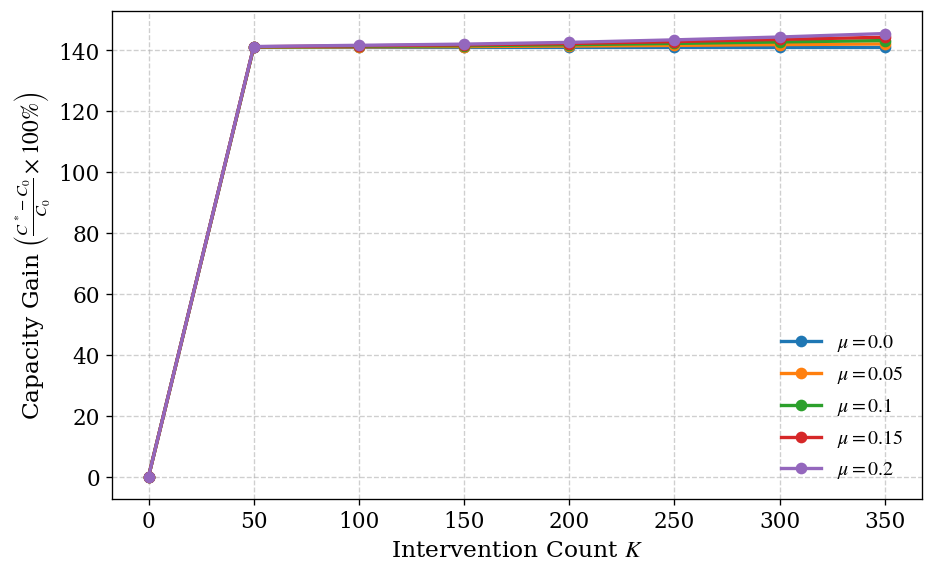

In [104]:
# ===== PLOT =====
plt.figure(figsize=(8, 5))

for mu in mu_list:
    plt.plot(
        K_vals,
        results_K[mu],
        marker='o',
        linewidth=2,
        label=fr'$\mu = {mu}$'
    )

plt.xlabel(r'Intervention Count $K$', fontsize=14)
plt.ylabel(
    r'Capacity Gain $\left(\frac{C^* - C_0}{C_0} \times 100\%\right)$',
    fontsize=14
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

lambda=1.000e-06, status=optimal, K=74, C=0.5389
lambda=1.778e-06, status=optimal, K=74, C=0.5389
lambda=3.162e-06, status=optimal, K=74, C=0.5389
lambda=5.623e-06, status=optimal, K=74, C=0.5389
lambda=1.000e-05, status=optimal, K=74, C=0.5389
lambda=1.778e-05, status=optimal, K=74, C=0.5389
lambda=3.162e-05, status=optimal, K=74, C=0.5389
lambda=5.623e-05, status=optimal, K=74, C=0.5389
lambda=1.000e-04, status=optimal, K=74, C=0.5389
lambda=1.778e-04, status=optimal, K=74, C=0.5389
lambda=3.162e-04, status=optimal, K=74, C=0.5389
lambda=5.623e-04, status=optimal, K=74, C=0.5389
lambda=1.000e-03, status=optimal, K=74, C=0.5389
lambda=1.778e-03, status=optimal, K=74, C=0.5389
lambda=3.162e-03, status=optimal, K=74, C=0.5389
lambda=5.623e-03, status=optimal, K=74, C=0.5389
lambda=1.000e-02, status=optimal, K=74, C=0.5389
lambda=1.778e-02, status=optimal, K=74, C=0.5389
lambda=3.162e-02, status=optimal, K=74, C=0.5389
lambda=5.623e-02, status=optimal, K=68, C=0.5269
lambda=1.000e-01, st

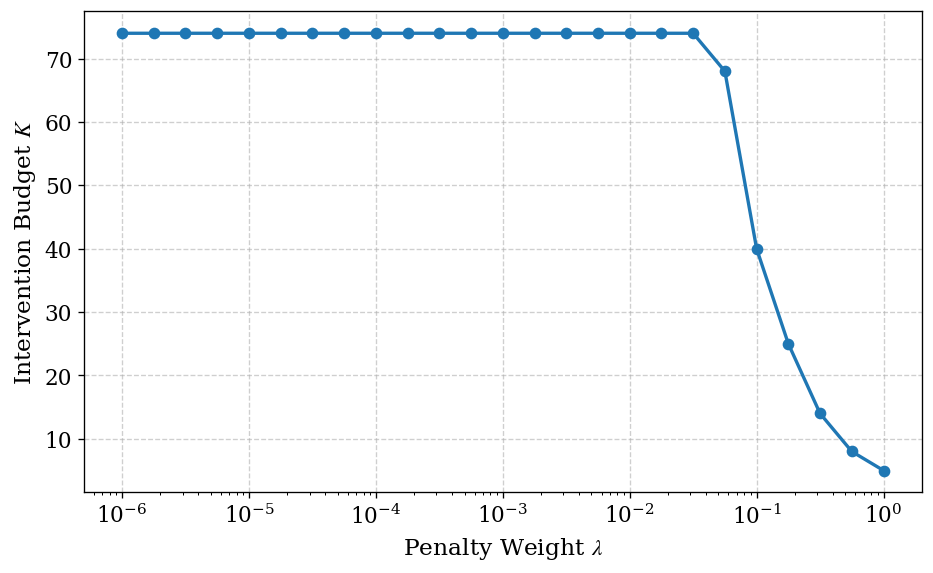

In [ ]:
def lambda_vs_intervention_budget(
    C_res,
    lhat,
    alpha=0.95,
    mu=0.10,
    lam_vals=None,
    solver="CLARABEL",
    tol=1e-6,
):
    if lam_vals is None:
        lam_vals = np.logspace(-6, 0, 20)

    K_vals = []
    C_vals = []
    eta_vals = []
    status_vals = []

    for lam in lam_vals:
        res = optimization(
            C_res=C_res,
            lhat=lhat,
            alpha=alpha,
            mu=mu,
            lam=lam,
            solver=solver,
            verbose=False
        )

        status_vals.append(res["status"])

        if res["status"] not in ["optimal", "optimal_inaccurate"] or res["u"] is None:
            K_vals.append(np.nan)
            C_vals.append(np.nan)
            eta_vals.append(np.nan)
            print(f"lambda={lam:.3e}, status={res['status']}, K=nan")
            continue

        u = np.asarray(res["u"]).flatten()
        K_actual = np.sum(u > tol)

        K_vals.append(K_actual)
        C_vals.append(res["C"])
        eta_vals.append(res["eta"])

        print(
            f"lambda={lam:.3e}, "
            f"status={res['status']}, "
            f"K={K_actual}, "
            f"C={res['C']:.4f}"
        )

    return {
        "lam_vals": np.array(lam_vals),
        "K_vals": np.array(K_vals),
        "C_vals": np.array(C_vals),
        "eta_vals": np.array(eta_vals),
        "status_vals": status_vals,
    }


# ===== RUN =====
lam_vals = np.logspace(-6, 0, 25)

res_lam = lambda_vs_intervention_budget(
    C_res=C_res,
    lhat=lhat,
    alpha=0.95,
    mu=0.10,
    lam_vals=lam_vals,
    solver="CLARABEL",
    tol=1e-6,
)

# ===== PLOT =====
plt.figure(figsize=(8, 5))
plt.plot(
    res_lam["lam_vals"],
    res_lam["K_vals"],
    marker='o',
    linewidth=2
)

plt.xscale('log')
plt.xlabel(r'Penalty Weight $\lambda$', fontsize=14)
plt.ylabel(r'Intervention Budget $K$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Hosting capacity vs confidence level

In [ ]:
# Hosting capacity in KW vs alpha for different mu values

alpha_vals = np.linspace(0.0, 0.99, 12)

mu_list = [0.0, 0.05, 0.10, 0.15, 0.20]

results = {}

for mu in mu_list:
    C_opt_kw = []
    
    print(f"\n===== Running for mu = {mu} =====")
    
    for alpha in alpha_vals:
        res = optimization(
            C_res=C_res,
            lhat=lhat,
            alpha=alpha,
            mu=mu,
            solver="CLARABEL",
            verbose=False,
            lam=1e-4
        )

        if res["status"] not in ["optimal", "optimal_inaccurate"]:
            print(f"alpha={alpha:.2f}, status={res['status']}")
            C_opt_kw.append(np.nan)
        else:
            C_kw = res["C"] * S_base
            C_opt_kw.append(C_kw)

            print(f"alpha={alpha:.2f}, C*_kW={C_kw:.2f}")

    results[mu] = np.array(C_opt_kw)

# ===== PLOT =====
plt.figure(figsize=(8,5))

for mu in mu_list:
    plt.plot(
        alpha_vals,
        results[mu],
        marker='o',
        linewidth=2,
        label=fr'$\mu = {mu}$'
    )

plt.xlabel(r'Risk Level $\alpha$', fontsize=14)
plt.ylabel('Hosting Capacity (kW)', fontsize=14)
# plt.title('Hosting Capacity vs Risk Level for Different Curtailment Limits', fontsize=15)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [39]:
alpha_vals = np.linspace(0.8, 0.99, 12)
mu_list = [0.0, 0.05, 0.10, 0.15, 0.20]

results_kw = {}

tol = 1e-9
mask = lhat > tol
C_base = np.min(C_res[mask] / lhat[mask])     # per-unit capacity
C_base_kw = C_base * S_base

print(f"No-flexibility baseline capacity = {C_base:.4f} p.u. = {C_base_kw:.2f} kW")


for mu in mu_list:
    gain_vals = []

    print(f"\n===== Running for mu = {mu} =====")

    for alpha in alpha_vals:
        res = optimization(
            C_res=C_res,
            lhat=lhat,
            alpha=alpha,
            mu=mu,
            solver="CLARABEL",
            verbose=False,
            lam=1e-4
        )

        if res["status"] not in ["optimal", "optimal_inaccurate"] or res["C"] is None:
            gain_vals.append(np.nan)
            print(f"alpha={alpha:.2f}, status={res['status']}, gain=nan")
        else:
            C_kw = res["C"] * S_base
            gain_pct = 100.0 * (C_kw - C_base_kw) / C_base_kw
            gain_vals.append(gain_pct)

            print(
                f"alpha={alpha:.2f}, "
                f"C*={C_kw:.2f} kW, "
                f"gain={gain_pct:.2f}%"
            )

    results_kw[mu] = np.array(gain_vals)



No-flexibility baseline capacity = 0.3760 p.u. = 162.72 kW

===== Running for mu = 0.0 =====
alpha=0.80, C*=162.72 kW, gain=0.00%
alpha=0.82, C*=162.72 kW, gain=0.00%
alpha=0.83, C*=162.72 kW, gain=0.00%
alpha=0.85, C*=162.72 kW, gain=0.00%
alpha=0.87, C*=162.72 kW, gain=0.00%
alpha=0.89, C*=162.72 kW, gain=0.00%
alpha=0.90, C*=162.72 kW, gain=0.00%
alpha=0.92, C*=162.72 kW, gain=0.00%
alpha=0.94, C*=162.72 kW, gain=0.00%
alpha=0.96, C*=162.72 kW, gain=0.00%
alpha=0.97, C*=162.72 kW, gain=0.00%
alpha=0.99, C*=162.72 kW, gain=0.00%

===== Running for mu = 0.05 =====
alpha=0.80, C*=267.31 kW, gain=64.27%
alpha=0.82, C*=260.99 kW, gain=60.39%
alpha=0.83, C*=254.51 kW, gain=56.40%
alpha=0.85, C*=247.80 kW, gain=52.28%
alpha=0.87, C*=240.97 kW, gain=48.09%
alpha=0.89, C*=234.42 kW, gain=44.06%
alpha=0.90, C*=227.94 kW, gain=40.08%
alpha=0.92, C*=220.80 kW, gain=35.69%
alpha=0.94, C*=212.62 kW, gain=30.66%
alpha=0.96, C*=202.93 kW, gain=24.71%
alpha=0.97, C*=193.57 kW, gain=18.96%
alpha=0.99

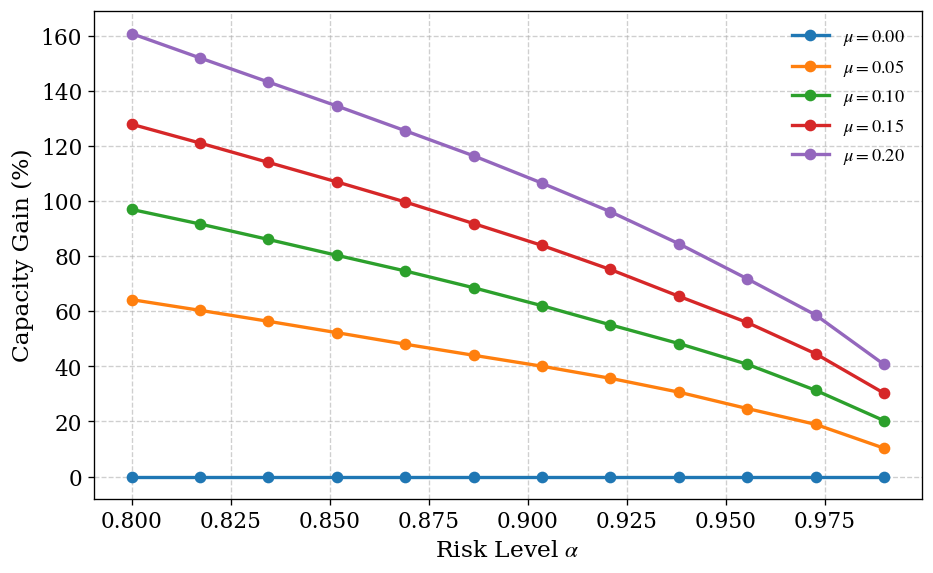

In [41]:
plt.figure(figsize=(8, 5))

for mu in mu_list:
    plt.plot(
        alpha_vals,
        results_kw[mu],
        marker='o',
        linewidth=2,
        label=fr'$\mu={mu:.2f}$'
    )

plt.xlabel(r'Risk Level $\alpha$', fontsize=14)
plt.ylabel('Capacity Gain (%)', fontsize=14)
# plt.title('Capacity Gain vs Risk Level for Different Curtailment Limits', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Load curtailment plot

In [67]:
best_res, best_lambda = tune_lambda_for_K(
    C_res=C_res,
    lhat=lhat,
    K_target=350,
    alpha=0.95,
    mu=0.2,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol_K=5,
    solver="CLARABEL"
)

Iter 0: lam=5.0000e-01, K=9, C=179.85 kW
Iter 1: lam=2.5000e-01, K=18, C=188.29 kW
Iter 2: lam=1.2500e-01, K=34, C=206.24 kW
Iter 3: lam=6.2501e-02, K=62, C=223.01 kW
Iter 4: lam=3.1251e-02, K=117, C=254.97 kW
Iter 5: lam=1.5626e-02, K=210, C=286.12 kW
Iter 6: lam=7.8135e-03, K=210, C=286.12 kW
Iter 7: lam=3.9072e-03, K=210, C=286.12 kW
Iter 8: lam=1.9541e-03, K=210, C=286.12 kW
Iter 9: lam=9.7756e-04, K=210, C=286.12 kW
Iter 10: lam=4.8928e-04, K=210, C=286.12 kW
Early stopping: K unchanged for 5 iterations


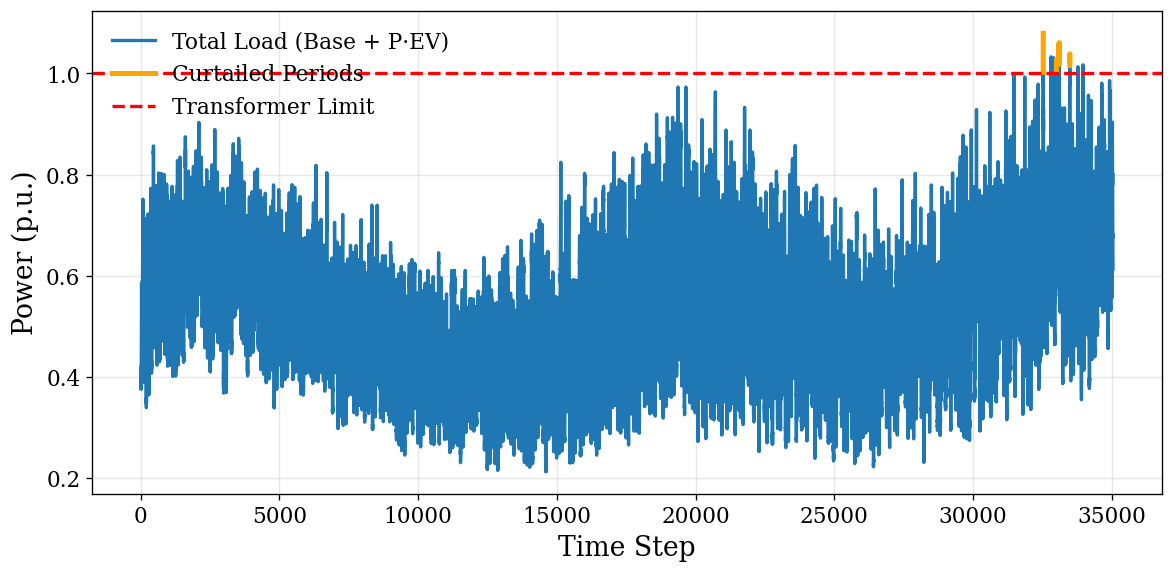

In [67]:
t = np.arange(T)

# Total load
total_load = bus_load_pu.sum(axis=1) + best_res['C'] * lhat

# Curtailment
u = best_res['u']
tol = 1e-6
curt_idx = u > tol   # where curtailment happens

# masked version for highlighting
curt_load = np.full_like(total_load, np.nan)
curt_load[curt_idx] = total_load[curt_idx]

limit = 1.0

plt.figure(figsize=(10, 5))

# Base load curve
plt.plot(t, total_load, linewidth=2, label="Total Load (Base + P·EV)")


plt.plot(t, curt_load, linewidth=3, color='orange', label="Curtailed Periods")

plt.axhline(limit, color='red', linestyle='--', linewidth=2, label="Transformer Limit")
plt.xlabel("Time Step")
plt.ylabel("Power (p.u.)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

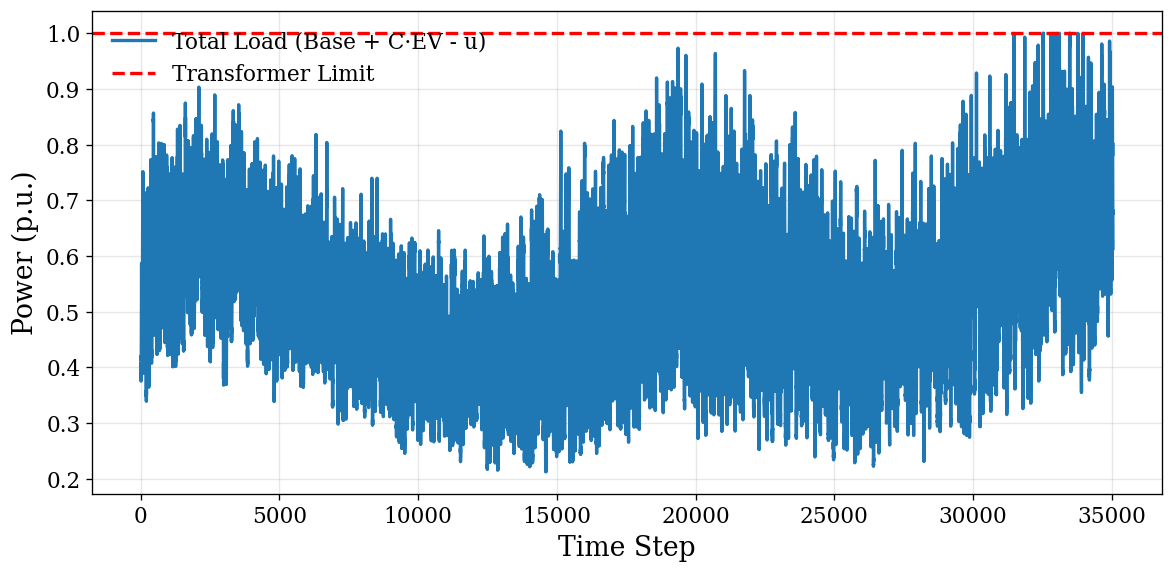

In [68]:
t = np.arange(T)
total_load = bus_load_pu.sum(axis=1) + best_res['C'] * lhat - best_res['u']

limit = 1.0
plt.figure(figsize=(10, 5))
plt.plot(t, total_load, linewidth=2, label="Total Load (Base + C·EV - u)")
plt.axhline(limit, color='red', linestyle='--', linewidth=2, label="Transformer Limit")

plt.xlabel("Time Step")
plt.ylabel("Power (p.u.)")
plt.legend()
plt.show()

Text(0, 0.5, 'Curtailment (p.u.)')

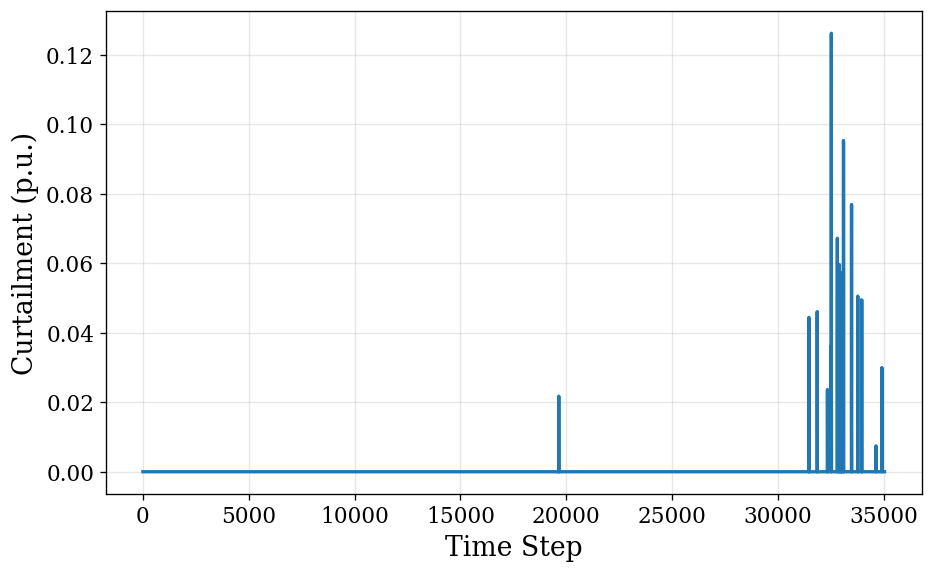

In [38]:
plt.plot(t, best_res['u'], label='Curtailment u')
plt.xlabel("Time Step")
plt.ylabel("Curtailment (p.u.)")

### CVAR Tail

In [80]:
T = len(C_res)
k_target = 3500
alpha = 1 - K_target / T
mu = 0.2

best_res, best_lambda = tune_lambda_for_K(
    C_res=C_res,
    lhat=lhat,
    K_target=K_target,
    alpha=alpha,
    mu=mu,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol_K=5,
    solver="CLARABEL"
)

Iter 0: lam=5.0000e-01, K=9, C=179.85 kW
Iter 1: lam=2.5000e-01, K=18, C=188.29 kW
Iter 2: lam=1.2500e-01, K=29, C=203.41 kW
Iter 3: lam=6.2501e-02, K=29, C=203.41 kW
Iter 4: lam=3.1251e-02, K=29, C=203.41 kW
Iter 5: lam=1.5626e-02, K=29, C=203.41 kW
Iter 6: lam=7.8135e-03, K=29, C=203.41 kW
Iter 7: lam=3.9072e-03, K=29, C=203.41 kW
Early stopping: K unchanged for 5 iterations


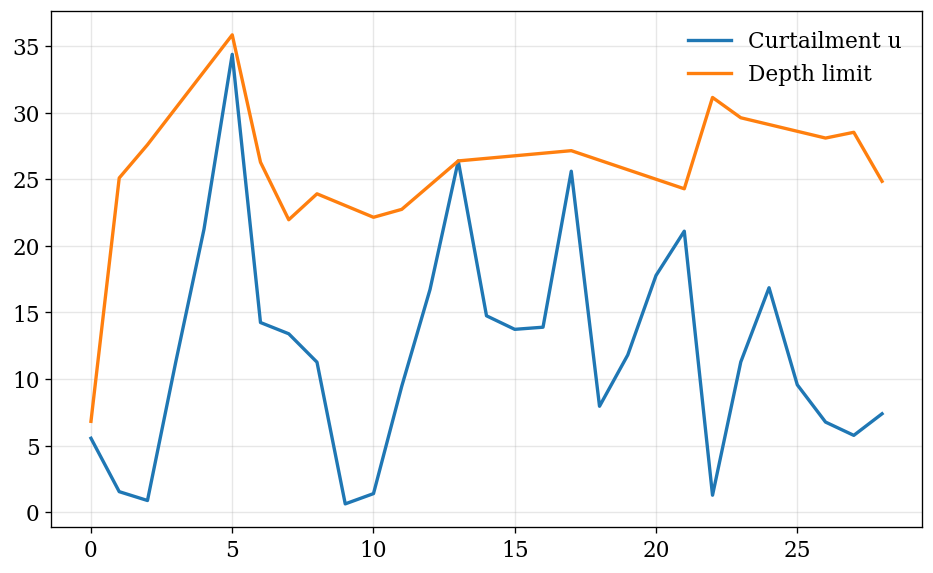

In [66]:
plt.plot(best_res['u'][best_res['u'] > 1e-6]*S_base, label='Curtailment u')
plt.plot(best_res['C']*mu*lhat[best_res['u']*S_base > 1e-6]*S_base, label='Depth limit')
plt.legend()

In [70]:

def cvar_cdf(res, lhat, mu, alpha=0.95):
    C = res["C"]
    u = np.asarray(res["u"]).flatten()

    z = u - mu * C * lhat
    z_sorted = np.sort(z)
    T = len(z)

    cdf = np.arange(1, T + 1) / T

    # VaR and CVaR
    var_alpha = np.quantile(z, alpha)
    cvar_alpha = z[z >= var_alpha].mean()

    plt.figure(figsize=(8, 4))

    # CDF
    plt.plot(z_sorted, cdf, linewidth=2)

    # key vertical lines
    plt.axvline(0, linestyle="--", linewidth=2, label="0 (no violation)")
    plt.axvline(var_alpha, linestyle="--", linewidth=2, label=f"VaR ({alpha})")
    plt.axvline(cvar_alpha, linestyle="-", linewidth=2, label="CVaR")

    plt.xlabel(r"$z_t$")
    plt.ylabel("CDF")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

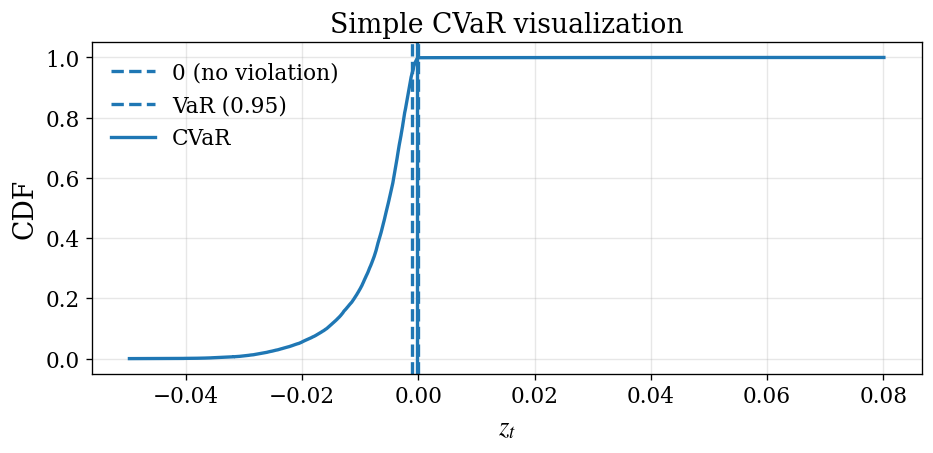

In [42]:
cdf_info = cvar_cdf(best_res, lhat, mu=0.10, alpha=0.95)